In [519]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast

In [520]:
data = pd.read_csv('kickstarter.csv')
data.head()

,id,name,blurb,goal,pledged,state,slug,country,country_displayable_name,currency,...,category,video,profile,spotlight,urls,percent_funded,is_liked,is_disliked,is_launched,prelaunch_activated
0,386902354,MY LITTLE PONY: Friendship is Magic Rainbow Co...,The sparkliest and most iconic moments from th...,25000.0,64002.0,live,my-little-pony-friendship-is-magic-rainbow-col...,US,the United States,USD,...,"{'id': 250, 'name': 'Comic Books', 'analytics_...",NaN,"{'id': 5279484, 'project_id': 5279484, 'state'...",False,{'web': {'project': 'https://www.kickstarter.c...,256.008000,False,False,True,True
1,632098548,How to THINK when you DRAW BOOK 9 + REPRINTS +...,The 9th 200 PAGE BOOK of Lorenzo Etherington's...,1000.0,341824.0,live,how-to-think-when-you-draw-book-9-reprints-ink...,GB,the United Kingdom,GBP,...,"{'id': 3, 'name': 'Comics', 'analytics_name': ...","{'id': 1413171, 'status': 'successful', 'hls':...","{'id': 5325805, 'project_id': 5325805, 'state'...",False,{'web': {'project': 'https://www.kickstarter.c...,34182.400000,False,False,True,False
2,1058096422,stare down. Volumes 1 & 2,"The story of Nil, who misconstrues an enamoure...",3000.0,8581.0,live,stare-down-webtoon-volumes-1-and-2,US,the United States,USD,...,"{'id': 252, 'name': 'Graphic Novels', 'analyti...","{'id': 1423417, 'status': 'successful', 'hls':...","{'id': 5329619, 'project_id': 5329619, 'state'...",False,{'web': {'project': 'https://www.kickstarter.c...,286.033333,False,False,True,True
3,559582035,Tales of Asunda Tome + New Untamed Comic & D&D...,StrangerComics PRESENTS: Deluxe Fantasy Omnibu...,10000.0,89828.0,live,the-untamed-wishing-well-1-tales-of-asunda-tome,US,the United States,USD,...,"{'id': 252, 'name': 'Graphic Novels', 'analyti...","{'id': 1421552, 'status': 'successful', 'hls':...","{'id': 5313352, 'project_id': 5313352, 'state'...",False,{'web': {'project': 'https://www.kickstarter.c...,898.280000,False,False,True,True
4,1828445616,Hallowed Ground - An Afterlife Horror Comic An...,A 100+ Page Horror Anthology. Twelve stories o...,35000.0,10417.0,live,afterlife1,US,the United States,USD,...,"{'id': 252, 'name': 'Graphic Novels', 'analyti...",NaN,"{'id': 5315571, 'project_id': 5315571, 'state'...",False,{'web': {'project': 'https://www.kickstarter.c...,29.762857,False,False,True,True


In [521]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17996 entries, 0 to 17995
Data columns (total 40 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  17996 non-null  int64  
 1   name                                17996 non-null  object 
 2   blurb                               17986 non-null  object 
 3   goal                                17996 non-null  float64
 4   pledged                             17996 non-null  float64
 5   state                               17996 non-null  object 
 6   slug                                17996 non-null  object 
 7   country                             17996 non-null  object 
 8   country_displayable_name            17996 non-null  object 
 9   currency                            17996 non-null  object 
 10  currency_symbol                     17996 non-null  object 
 11  currency_trailing_code              17996

In [522]:
data.duplicated().sum()

np.int64(0)

In [523]:
#проверили, как именно связаны pledged и usd_pledged
#data["usd_pledged_calc"] = data["pledged"]*data['static_usd_rate']
#data[data["usd_pledged"]!=data["usd_pledged_calc"] ][['pledged', 'usd_pledged', 'usd_pledged_calc']]

дубликатов нет)

Сначала избавимся от признаков, которые не несут для нашей задачи пользы
удаляем:   
 6   slug - Часть URL-адреса проекта (то, что идет после домена) Используется для формирования красивых ссылок                        
 10  currency_symbol - Символ валюты                        
 11  currency_trailing_code - True/False Обычно значит, пишется ли символ валюты после суммы (как 100$) или до (как $100)                         
 18  is_starrable - Можно ли поставить «звезду» (добавить в избранное)                          
 19  disable_communication - Запрещено ли общение в комментариях (True/False)                 
 23  converted_pledged_amount - Дублирует usd_pledged с учетом фиксированного курса платформы
 24 fx_rate - Текущий обменный курс валюты проекта                              
 25  usd_exchange_rate - Курс обмена к USD (иногда отличается от `fx_rate` методикой расчета)         
 26  current_currency - Валюта, в которой сейчас отображаются суммы на странице(везде USD)                
 27  usd_type - Тип конвертации в USD                                   
 29  location - Данные о городе                             
 32  profile - Дополнительные настройки профиля  
 34  urls - Ссылки на веб-версию проекта и страницу наград                                    
 36  is_liked / 37  is_disliked Лайкнул/дизлайкнул ли текущий пользователь                                            


In [524]:
data = data.drop(['slug', 'currency_symbol','currency_trailing_code','is_starrable','disable_communication','converted_pledged_amount','usd_exchange_rate','current_currency','usd_type','profile','is_liked','is_disliked','location','fx_rate','urls'], axis=1)

In [525]:
data.head(5)

,id,name,blurb,goal,pledged,state,country,country_displayable_name,currency,deadline,...,backers_count,static_usd_rate,usd_pledged,creator,category,video,spotlight,percent_funded,is_launched,prelaunch_activated
0,386902354,MY LITTLE PONY: Friendship is Magic Rainbow Co...,The sparkliest and most iconic moments from th...,25000.0,64002.0,live,US,the United States,USD,1777572005,...,173,1.000,64002.000000,"{'id': 1690343815, 'name': 'BOOM! Studios', 's...","{'id': 250, 'name': 'Comic Books', 'analytics_...",NaN,False,256.008000,True,True
1,632098548,How to THINK when you DRAW BOOK 9 + REPRINTS +...,The 9th 200 PAGE BOOK of Lorenzo Etherington's...,1000.0,341824.0,live,GB,the United Kingdom,GBP,1775502000,...,3926,1.348,460778.605016,"{'id': 1378058646, 'name': 'Lorenzo Etheringto...","{'id': 3, 'name': 'Comics', 'analytics_name': ...","{'id': 1413171, 'status': 'successful', 'hls':...",False,34182.400000,True,False
2,1058096422,stare down. Volumes 1 & 2,"The story of Nil, who misconstrues an enamoure...",3000.0,8581.0,live,US,the United States,USD,1777489656,...,119,1.000,8581.000000,"{'id': 769898516, 'name': 'Rocketship', 'slug'...","{'id': 252, 'name': 'Graphic Novels', 'analyti...","{'id': 1423417, 'status': 'successful', 'hls':...",False,286.033333,True,True
3,559582035,Tales of Asunda Tome + New Untamed Comic & D&D...,StrangerComics PRESENTS: Deluxe Fantasy Omnibu...,10000.0,89828.0,live,US,the United States,USD,1776704517,...,408,1.000,89828.000000,"{'id': 1182319554, 'name': 'Sebastian A. Jones...","{'id': 252, 'name': 'Graphic Novels', 'analyti...","{'id': 1421552, 'status': 'successful', 'hls':...",False,898.280000,True,True
4,1828445616,Hallowed Ground - An Afterlife Horror Comic An...,A 100+ Page Horror Anthology. Twelve stories o...,35000.0,10417.0,live,US,the United States,USD,1776996000,...,224,1.000,10417.000000,"{'id': 1376978156, 'name': 'Deathline (from Li...","{'id': 252, 'name': 'Graphic Novels', 'analyti...",NaN,False,29.762857,True,True


Проверяем на пропуски:

In [526]:
data.isna().sum()

,0
id,0
name,0
blurb,10
goal,0
pledged,0
state,0
country,0
country_displayable_name,0
currency,0
deadline,0


Пропуски в blurb значат, что просто нет описания у проекта. Такое бывает, это не ошибка. Автор просто решил, что он без описания сделает сборы

Пропуски в video также не являются ошибкой. Значит, у проекта нет прикрепленного видео

In [527]:
data[data['usd_pledged'].isna()]['pledged'].unique()

array([0.])

пропуски в 'usd_pledged' это 0 в 'pledged'. Так что заполним пропуски 0

In [528]:
data['usd_pledged'] = data['usd_pledged'].fillna(0)

In [529]:
data['video'] = data['video'].fillna('')  #дальше пригодится
data['blurb'] = data['blurb'].fillna('')

In [530]:
# перводим в формат даты то, что является датой
data['state_changed_at'] = pd.to_datetime(data['state_changed_at'],unit='s')
data['deadline'] = pd.to_datetime(data['deadline'],unit='s')
data['created_at'] = pd.to_datetime(data['created_at'],unit='s')
data['launched_at'] = pd.to_datetime(data['launched_at'],unit='s')

теперь раскроем все вложенные данные

In [531]:
data['creator']

,creator
0,"{'id': 1690343815, 'name': 'BOOM! Studios', 's..."
1,"{'id': 1378058646, 'name': 'Lorenzo Etheringto..."
2,"{'id': 769898516, 'name': 'Rocketship', 'slug'..."
3,"{'id': 1182319554, 'name': 'Sebastian A. Jones..."
4,"{'id': 1376978156, 'name': 'Deathline (from Li..."
...,...
17991,"{'id': 787851171, 'name': 'Legends of Hapax', ..."
17992,"{'id': 1263999445, 'name': 'Dungeons & Dreadno..."
17993,"{'id': 437928348, 'name': '涼宮隼十 / パトスプロジェクト', ..."
17994,"{'id': 278762704, 'name': 'ASM-Games', 'slug':..."


In [532]:
data['creator'] = data['creator'].apply(ast.literal_eval)
creator_df = pd.json_normalize(data['creator'])
creator_df

,id,name,slug,is_registered,is_email_verified,chosen_currency,is_superbacker,has_admin_message_badge,partner_badge,ppo_has_action,backing_action_count,avatar.thumb,avatar.small,avatar.medium,urls.web.user,urls.api.user,is_ksr_admin
0,1690343815,BOOM! Studios,boom-studios,None,None,None,None,False,None,False,0,https://i.kickstarter.com/assets/052/388/145/a...,https://i.kickstarter.com/assets/052/388/145/a...,https://i.kickstarter.com/assets/052/388/145/a...,https://www.kickstarter.com/profile/boom-studios,https://api.kickstarter.com/v1/users/169034381...,NaN
1,1378058646,Lorenzo Etherington,thinkdraw7,None,None,None,None,False,None,False,0,https://i.kickstarter.com/assets/052/498/845/c...,https://i.kickstarter.com/assets/052/498/845/c...,https://i.kickstarter.com/assets/052/498/845/c...,https://www.kickstarter.com/profile/thinkdraw7,https://api.kickstarter.com/v1/users/137805864...,NaN
2,769898516,Rocketship,rocketship,None,None,None,None,False,None,False,0,https://i.kickstarter.com/assets/024/347/567/1...,https://i.kickstarter.com/assets/024/347/567/1...,https://i.kickstarter.com/assets/024/347/567/1...,https://www.kickstarter.com/profile/rocketship,https://api.kickstarter.com/v1/users/769898516...,NaN
3,1182319554,Sebastian A. Jones,sebastianajones,None,None,None,None,False,None,True,7,https://i.kickstarter.com/assets/007/417/981/0...,https://i.kickstarter.com/assets/007/417/981/0...,https://i.kickstarter.com/assets/007/417/981/0...,https://www.kickstarter.com/profile/sebastiana...,https://api.kickstarter.com/v1/users/118231955...,NaN
4,1376978156,Deathline (from Lifeline Comics),deathline,None,None,None,None,False,None,False,0,https://i.kickstarter.com/assets/050/952/772/3...,https://i.kickstarter.com/assets/050/952/772/3...,https://i.kickstarter.com/assets/050/952/772/3...,https://www.kickstarter.com/profile/deathline,https://api.kickstarter.com/v1/users/137697815...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17991,787851171,Legends of Hapax,projectapax,None,None,None,None,False,None,False,0,https://i.kickstarter.com/assets/041/228/299/8...,https://i.kickstarter.com/assets/041/228/299/8...,https://i.kickstarter.com/assets/041/228/299/8...,https://www.kickstarter.com/profile/projectapax,https://api.kickstarter.com/v1/users/787851171...,NaN
17992,1263999445,Dungeons & Dreadnoughts,dungeonndreadnought,None,None,None,None,False,None,False,0,https://i.kickstarter.com/assets/047/951/813/c...,https://i.kickstarter.com/assets/047/951/813/c...,https://i.kickstarter.com/assets/047/951/813/c...,https://www.kickstarter.com/profile/dungeonndr...,https://api.kickstarter.com/v1/users/126399944...,NaN
17993,437928348,涼宮隼十 / パトスプロジェクト,pathosproject,None,None,None,None,False,None,False,0,https://i.kickstarter.com/assets/045/857/675/b...,https://i.kickstarter.com/assets/045/857/675/b...,https://i.kickstarter.com/assets/045/857/675/b...,https://www.kickstarter.com/profile/pathosproject,https://api.kickstarter.com/v1/users/437928348...,NaN
17994,278762704,ASM-Games,asm-games,None,None,None,None,False,None,False,0,https://i.kickstarter.com/assets/032/012/812/4...,https://i.kickstarter.com/assets/032/012/812/4...,https://i.kickstarter.com/assets/032/012/812/4...,https://www.kickstarter.com/profile/asm-games,https://api.kickstarter.com/v1/users/278762704...,NaN


добавим в наш датасет только нужные столбцы

In [533]:
creator_df = creator_df.add_prefix('creator_')
data = pd.concat([data, creator_df['creator_id']], axis=1)
data = pd.concat([data, creator_df['creator_name']], axis=1)
data = pd.concat([data, creator_df['creator_is_registered']], axis=1)
data = pd.concat([data, creator_df['creator_is_ksr_admin']], axis=1)
data = pd.concat([data, creator_df['creator_is_superbacker']], axis=1)


In [534]:
data['category'] = data['category'].apply(ast.literal_eval)
category_df = pd.json_normalize(data['category'])
category_df

,id,name,analytics_name,slug,position,parent_id,parent_name,color,urls.web.discover
0,250,Comic Books,Comic Books,comics/comic books,2,3.0,Comics,16776056,http://www.kickstarter.com/discover/categories...
1,3,Comics,Comics,comics,2,NaN,NaN,16776056,http://www.kickstarter.com/discover/categories...
2,252,Graphic Novels,Graphic Novels,comics/graphic novels,4,3.0,Comics,16776056,http://www.kickstarter.com/discover/categories...
3,252,Graphic Novels,Graphic Novels,comics/graphic novels,4,3.0,Comics,16776056,http://www.kickstarter.com/discover/categories...
4,252,Graphic Novels,Graphic Novels,comics/graphic novels,4,3.0,Comics,16776056,http://www.kickstarter.com/discover/categories...
...,...,...,...,...,...,...,...,...,...
17991,35,Video Games,Video Games,games/video games,7,12.0,Games,51627,http://www.kickstarter.com/discover/categories...
17992,34,Tabletop Games,Tabletop Games,games/tabletop games,6,12.0,Games,51627,http://www.kickstarter.com/discover/categories...
17993,34,Tabletop Games,Tabletop Games,games/tabletop games,6,12.0,Games,51627,http://www.kickstarter.com/discover/categories...
17994,35,Video Games,Video Games,games/video games,7,12.0,Games,51627,http://www.kickstarter.com/discover/categories...


In [535]:
category_df = category_df.add_prefix('category_')
data = pd.concat([data, category_df['category_id']], axis=1)
data = pd.concat([data, category_df['category_name']], axis=1)
data = pd.concat([data, category_df['category_slug']], axis=1)
data = pd.concat([data, category_df['category_parent_id']], axis=1)
data = pd.concat([data, category_df['category_parent_name']], axis=1)

In [536]:
data['video']= data['video'][data['video']!=""].apply(ast.literal_eval)
video_df = pd.json_normalize(data['video'])
video_df

,id,status,hls,hls_type,high,high_type,base,base_type,tracks,width,height,frame
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1413171.0,successful,https://v2.kickstarter.com/1774905984-BtmLSvI1...,application/x-mpegURL,https://v2.kickstarter.com/1774905984-BtmLSvI1...,"video/mp4; codecs=""avc1.64001E, mp4a.40.2""",https://v2.kickstarter.com/1774905984-BtmLSvI1...,"video/mp4; codecs=""avc1.42E01E, mp4a.40.2""",[],1280.0,720.0,https://d15chbti7ht62o.cloudfront.net/projects...
2,1423417.0,successful,https://v2.kickstarter.com/1774901730-LMFhnhqA...,application/x-mpegURL,https://v2.kickstarter.com/1774901730-LMFhnhqA...,"video/mp4; codecs=""avc1.64001E, mp4a.40.2""",https://v2.kickstarter.com/1774901730-LMFhnhqA...,"video/mp4; codecs=""avc1.42E01E, mp4a.40.2""",[],1280.0,720.0,https://d15chbti7ht62o.cloudfront.net/projects...
3,1421552.0,successful,https://v2.kickstarter.com/1774982023-DW8K0B4u...,application/x-mpegURL,https://v2.kickstarter.com/1774982023-DW8K0B4u...,"video/mp4; codecs=""avc1.64001E, mp4a.40.2""",https://v2.kickstarter.com/1774982023-DW8K0B4u...,"video/mp4; codecs=""avc1.42E01E, mp4a.40.2""",[],1280.0,720.0,https://d15chbti7ht62o.cloudfront.net/projects...
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
17991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [537]:
video_df = video_df.add_prefix('video_')
data = pd.concat([data, video_df['video_id']], axis=1)

уиии такая умнички, идем дальше, надо убить все то, что разложили на части

In [538]:
data = data.drop(['creator','category','video'], axis=1)

In [539]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17996 entries, 0 to 17995
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   id                                  17996 non-null  int64         
 1   name                                17996 non-null  object        
 2   blurb                               17996 non-null  object        
 3   goal                                17996 non-null  float64       
 4   pledged                             17996 non-null  float64       
 5   state                               17996 non-null  object        
 6   country                             17996 non-null  object        
 7   country_displayable_name            17996 non-null  object        
 8   currency                            17996 non-null  object        
 9   deadline                            17996 non-null  datetime64[ns]
 10  state_changed_at      

In [540]:
data.duplicated().sum()

np.int64(1940)

как так то... надо глянуть

In [541]:
data[data.duplicated(keep=False)].sort_values(by = 'id' )

,id,name,blurb,goal,pledged,state,country,country_displayable_name,currency,deadline,...,creator_name,creator_is_registered,creator_is_ksr_admin,creator_is_superbacker,category_id,category_name,category_slug,category_parent_id,category_parent_name,video_id
14888,1594224,KeyStone A Cappella's Debut Album!,KeyStone A Cappella is recording our debut alb...,5000.0,8173.0,successful,US,the United States,USD,2014-09-01 03:59:00,...,KeyStone A Cappella,None,NaN,None,14,Music,music,NaN,NaN,406027.0
14587,1594224,KeyStone A Cappella's Debut Album!,KeyStone A Cappella is recording our debut alb...,5000.0,8173.0,successful,US,the United States,USD,2014-09-01 03:59:00,...,KeyStone A Cappella,None,NaN,None,14,Music,music,NaN,NaN,406027.0
14025,4202650,Ron Hall's Memphis: The Rock 'n Roll Years His...,Ron Hall's newest Memphis history book product...,3000.0,3063.0,successful,US,the United States,USD,2014-05-09 03:21:16,...,Sherman Willmott,None,NaN,None,43,Rock,music/rock,14.0,Music,352428.0
14912,4202650,Ron Hall's Memphis: The Rock 'n Roll Years His...,Ron Hall's newest Memphis history book product...,3000.0,3063.0,successful,US,the United States,USD,2014-05-09 03:21:16,...,Sherman Willmott,None,NaN,None,43,Rock,music/rock,14.0,Music,352428.0
15336,4202650,Ron Hall's Memphis: The Rock 'n Roll Years His...,Ron Hall's newest Memphis history book product...,3000.0,3063.0,successful,US,the United States,USD,2014-05-09 03:21:16,...,Sherman Willmott,None,NaN,None,43,Rock,music/rock,14.0,Music,352428.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9532,2143246629,Into The Well: Reclaiming the Stage as Sacred,Immersive dance production: A psychosexual thr...,45000.0,45021.0,successful,US,the United States,USD,2025-07-20 14:10:37,...,Sabina Lundgren,None,NaN,None,255,Residencies,dance/residencies,6.0,Dance,1366756.0
16023,2145544279,Future Boyfriend,A short comedic film about falling in love in ...,10000.0,12645.0,successful,US,the United States,USD,2014-08-05 07:00:00,...,Emily Bell and Ron Morehouse,None,NaN,None,292,Comedy,film & video/comedy,11.0,Film & Video,412770.0
5745,2145544279,Future Boyfriend,A short comedic film about falling in love in ...,10000.0,12645.0,successful,US,the United States,USD,2014-08-05 07:00:00,...,Emily Bell and Ron Morehouse,None,NaN,None,292,Comedy,film & video/comedy,11.0,Film & Video,412770.0
7775,2146767304,Unmethodical,A collection of some of my favorite photograph...,250.0,545.0,successful,US,the United States,USD,2021-05-31 01:00:00,...,Brian White,None,NaN,None,277,Nature,photography/nature,15.0,Photography,NaN


в строках были различия только внуутри словарей, но по сути проекты идентичны, так что придется поудалять дубли

In [542]:
data = data.drop_duplicates()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16056 entries, 0 to 17995
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   id                                  16056 non-null  int64         
 1   name                                16056 non-null  object        
 2   blurb                               16056 non-null  object        
 3   goal                                16056 non-null  float64       
 4   pledged                             16056 non-null  float64       
 5   state                               16056 non-null  object        
 6   country                             16056 non-null  object        
 7   country_displayable_name            16056 non-null  object        
 8   currency                            16056 non-null  object        
 9   deadline                            16056 non-null  datetime64[ns]
 10  state_changed_at           

In [543]:
data.isna().sum()

,0
id,0
name,0
blurb,0
goal,0
pledged,0
state,0
country,0
country_displayable_name,0
currency,0
deadline,0


In [544]:
print(len(data['name'].unique()))
data[data['name'].duplicated()].sort_values(by = 'name')

16025


,id,name,blurb,goal,pledged,state,country,country_displayable_name,currency,deadline,...,creator_name,creator_is_registered,creator_is_ksr_admin,creator_is_superbacker,category_id,category_name,category_slug,category_parent_id,category_parent_name,video_id
7871,848154913,3D Printable Pinball Machine - by 3D Printer A...,A 100% 3D printable desktop pinball machine th...,3000.0,39624.0,live,US,the United States,USD,2026-04-30 13:59:09,...,3D Printer Academy,None,NaN,None,331,3D Printing,technology/3d printing,16.0,Technology,1423448.0
7880,1954230549,Acres,Family Owned Feuding,25000.0,9477.0,live,US,the United States,USD,2026-04-21 14:00:51,...,Lucas McWhirter,None,NaN,None,34,Tabletop Games,games/tabletop games,12.0,Games,1419530.0
3074,1954230549,Acres,Family Owned Feuding,25000.0,6327.0,live,US,the United States,USD,2026-04-21 14:00:51,...,Lucas McWhirter,None,NaN,None,34,Tabletop Games,games/tabletop games,12.0,Games,1419530.0
3077,149159163,AdventureQuest Worlds: Infinity,"2D Fantasy MMORPG for your phone, tablet, and ...",1.0,1510079.0,live,US,the United States,USD,2026-04-06 19:00:00,...,"Artix Entertainment, LLC",None,NaN,None,35,Video Games,games/video games,12.0,Games,1418009.0
220,620865015,DEAD AT 17 / ZOMBIE TRAMP: Nara VS Janey Belle,Two indie horror icons collide!,5000.0,31099.0,live,US,the United States,USD,2026-04-02 04:00:00,...,Josh Howard,None,NaN,None,250,Comic Books,comics/comic books,3.0,Comics,NaN
3080,1863747469,"Dragon Roost, Prowl & Space Potato. A Tiny Gam...",3 Unique and Addictive New Tiny Games!,12500.0,7392.0,live,US,the United States,USD,2026-04-28 22:00:00,...,Envy Born Games,None,NaN,None,34,Tabletop Games,games/tabletop games,12.0,Games,1421308.0
3083,633809486,Drownlight,Drownlight is a city-building survival simulat...,65000.0,113182.0,live,US,the United States,USD,2026-04-23 15:00:02,...,Crytivo Games,None,NaN,None,35,Video Games,games/video games,12.0,Games,1422282.0
7872,2043800332,Dying Hard on Hardlight Station: Anthology Edi...,Return to Hardlight Station in this hardback M...,40000.0,257474.0,live,CA,Canada,CAD,2026-04-03 04:00:00,...,David Kenny,None,NaN,None,34,Tabletop Games,games/tabletop games,12.0,Games,1413080.0
17344,1850881552,Even The Stars Will Fall #1,Will the city state of Ara retain its sense of...,800.0,2216.0,successful,GB,the United Kingdom,GBP,2026-03-25 11:44:18,...,Folarin Akinmade,None,NaN,None,250,Comic Books,comics/comic books,3.0,Comics,NaN
7859,693089226,G.I. Joe: A Real American Hero Compendium Sets...,Definitive hardcover collections of the legend...,40000.0,1884346.0,live,US,the United States,USD,2026-04-22 19:00:00,...,Skybound,None,NaN,None,250,Comic Books,comics/comic books,3.0,Comics,1422533.0


есть повторы по имени, так как на парсинг потребовалось много времени, информация по некоторым проектам была обновлена, а именно сборы. Поэтому проекты дублируются полностью, а сборы чуть-чуть не равны

In [545]:
data = data.sort_values(by = 'pledged',ascending=False)
data = data.drop_duplicates(subset='name')

In [546]:
print(len(data['name'].unique()))

16025


в столбцах  creator_is_registered и creator_is_superbacker полностью пусто, здесь creator_is_ksr_admin всего три значения. Совершенно не нужны нам((

  category_parent_id,category_parent_name - здесь пустоты, потому что категория является родителем сама по себе, поэтому ни на кого не ссылкается. Поэтому проставим здесь 0, так "мама" категория


In [547]:
data = data.drop(['creator_is_registered','creator_is_superbacker','creator_is_ksr_admin'], axis=1)

In [548]:
data['category_parent_id'] = data['category_parent_id'].fillna(0)
data['category_parent_name'] = data['category_parent_name'].fillna("0")

In [549]:
data.isna().sum()

,0
id,0
name,0
blurb,0
goal,0
pledged,0
state,0
country,0
country_displayable_name,0
currency,0
deadline,0


In [550]:
data

,id,name,blurb,goal,pledged,state,country,country_displayable_name,currency,deadline,...,is_launched,prelaunch_activated,creator_id,creator_name,category_id,category_name,category_slug,category_parent_id,category_parent_name,video_id
3431,870254269,NestWorks C500 - Next-Gen Smartest CNC with In...,"800W, 18,000 RPM Spindle | 10× Productivity | ...",388633.0,95156996.0,successful,HK,Hong Kong,HKD,2025-12-19 14:00:05,...,True,True,959480926,NestWorks,335,Fabrication Tools,technology/fabrication tools,16.0,Technology,1396477.0
3373,235978012,"Makera Z1 Desktop CNC: Entry-level CNC, Pro-le...",Metal / Wood / Endless Materials | Industrial-...,776800.0,91196239.0,successful,HK,Hong Kong,HKD,2025-12-12 16:00:03,...,True,True,1413242727,Makera,335,Fabrication Tools,technology/fabrication tools,16.0,Technology,1395310.0
3425,1817989721,Mirumi: A Charm Robot that Steals a Glance—and...,"It spontaneously turns to you, and its innocen...",765000.0,79419523.0,successful,JP,Japan,JPY,2026-01-22 12:00:06,...,True,True,1477302345,Yukai Engineering,338,Robots,technology/robots,16.0,Technology,1402297.0
8412,1165004003,Smartflex Camera SLR 4x5,Large Format SLR System,4800000.0,51143292.0,successful,JP,Japan,JPY,2025-01-22 01:13:55,...,True,False,1981152066,Zhuoyao Chen,333,Camera Equipment,technology/camera equipment,16.0,Technology,NaN
3421,1173435412,"Melt Mouse: 3-in-1 mouse, trackpad, and shortc...","""The Melt Mouse Is A More Functional Version O...",5000000.0,49063717.0,successful,JP,Japan,JPY,2025-11-15 15:59:00,...,True,True,1623561485,Melt Interface,337,Gadgets,technology/gadgets,16.0,Technology,1395329.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4328,46276552,Sorcerer Anime Glow-in-Dark Enamel Pins Collec...,Click below to collect a wide range of your fa...,600.0,0.0,started,AU,Australia,AUD,2026-04-15 05:59:00,...,False,True,2001648450,Kraymer Art,1,Art,art,0.0,0,NaN
4329,574002330,🎃⚡🍭Spooky Dessert Parade,"“Join us, Gengi & Cleffi, as we conjure a coll...",10500.0,0.0,started,MX,Mexico,MXN,1970-01-01 00:00:00,...,False,True,1639242094,The lost forest,21,Digital Art,art/digital art,1.0,Art,NaN
4330,869277338,Colourful Life for the Ukrainian Refugees,Donate money to support the Ukrainian refugees...,0.0,0.0,submitted,GB,the United Kingdom,GBP,1970-01-01 00:00:00,...,False,True,1031410960,Joanna Maria Dziedzianowicz,22,Illustration,art/illustration,1.0,Art,NaN
4331,563551599,Elemen-teas Hard Enamel Pins,A series of whimsical tea pins,200.0,0.0,started,GB,the United Kingdom,GBP,1970-01-01 00:00:00,...,False,True,947353025,Abbey and Bear,1,Art,art,0.0,0,NaN


In [551]:
for i in data:
  print(i)
  print(data[i].unique())
  print()

id
[ 870254269  235978012 1817989721 ...  869277338  563551599  828408051]

name
['NestWorks C500 - Next-Gen Smartest CNC with Industrial Power'
 'Makera Z1 Desktop CNC: Entry-level CNC, Pro-level Power'
 'Mirumi: A Charm Robot that Steals a Glance—and Your Heart' ...
 'Colourful Life for the Ukrainian Refugees'
 'Elemen-teas Hard Enamel Pins' 'Thank You MA - NicoleRDS']

blurb
['800W, 18,000 RPM Spindle | 10× Productivity | Auto Tool Changer | ±0.02mm Precision | 3D Probe | MQL Coolant | 4-Axis | Hard-Metal CNC'
 'Metal / Wood / Endless Materials | Industrial-Grade Accuracy | Smart CNC Workflow | One-Click CAM Software | AI-Powered CNC Modeling'
 'It spontaneously turns to you, and its innocent gaze instantly lights up your heart, and your day.'
 ...
 'Donate money to support the Ukrainian refugees, and get a colouring book about the Ukrainian culture.'
 'A series of whimsical tea pins'
 'An art gallery/music showcase inspired by MA local music culture and dedicated to the creative co

In [552]:
round(data.describe(),1)

,id,goal,pledged,deadline,state_changed_at,created_at,launched_at,backers_count,static_usd_rate,usd_pledged,percent_funded,creator_id,category_id,category_parent_id,video_id
count,1.602500e+04,16025.0,16025.0,16025,16025,16025,16025,16025.0,16025.0,16025.0,16025.0,1.602500e+04,16025.0,16025.0,11558.0
mean,1.067392e+09,22765.0,108257.7,2011-07-17 23:01:36.068580608,2019-09-10 10:03:21.641746944,2019-06-09 14:12:05.923993600,2010-09-04 21:34:35.045865728,307.9,0.8,39472.9,10352.2,1.072403e+09,132.3,8.1,710350.3
min,1.971540e+05,0.0,0.0,1970-01-01 00:00:00,2009-05-03 07:00:17,2009-04-22 02:11:10,1970-01-01 00:00:00,0.0,0.0,0.0,0.0,8.000000e+00,1.0,0.0,111.0
25%,5.251617e+08,1000.0,1011.0,2012-04-04 18:58:34,2014-02-18 23:06:50,2013-11-11 18:35:45,2011-12-19 05:32:13,18.0,1.0,1001.0,100.3,5.304075e+08,25.0,1.0,229671.8
50%,1.070666e+09,5000.0,5630.0,2014-12-13 17:00:44,2020-05-25 22:34:43,2020-02-03 18:58:10,2014-09-05 03:09:07,78.0,1.0,5540.0,113.3,1.074243e+09,40.0,9.0,549076.5
75%,1.595406e+09,12000.0,19383.0,2025-04-06 21:00:00,2025-10-25 21:00:00,2025-06-20 05:50:27,2025-01-31 18:00:01,207.0,1.0,18348.0,183.3,1.603074e+09,263.0,14.0,1338345.8
max,2.147365e+09,20000000.0,95156996.0,2026-06-01 12:47:58,2026-04-02 13:20:58,2026-04-01 17:32:37,2026-04-02 13:20:55,48270.0,1.7,15133173.0,151007900.0,2.147433e+09,396.0,26.0,1424018.0
std,6.185359e+08,235641.0,1566354.3,NaN,NaN,NaN,NaN,1232.8,0.4,275034.4,1193411.6,6.201871e+08,128.2,6.6,526290.7


что смущает:

plegned|usd_plegned - различие между 75% и max

deadline|launched_at - данные с 1970 года, точно ли нам такие нужны? Первый квартиль уже 2012, старых данных немного

backers_count - максимум смущает

percent_funded - 184% это 75% от данных, а максимум 151млн%? Надо посмотреть


Можно точно сделать выводы, что есть выбросы. Давайте уберем старые проекты и выбросы в percent_funded




In [553]:
data = data[data['launched_at'] > '2000-01-01 00:00:00' ]

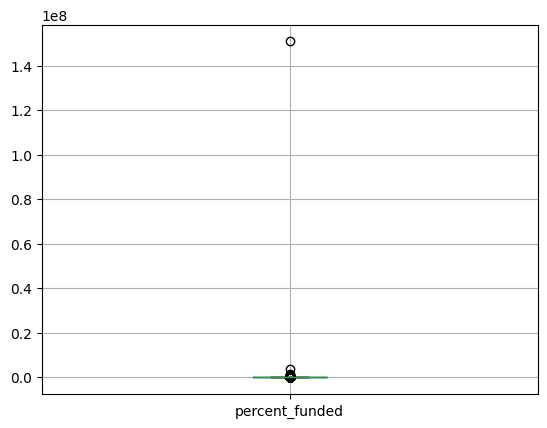

In [554]:
data.boxplot(column=['percent_funded'])
plt.show()

видим явныt выбросs. Удалим их

In [555]:
data[data['percent_funded'] > 100000 ]
# goal = 1,2

,id,name,blurb,goal,pledged,state,country,country_displayable_name,currency,deadline,...,is_launched,prelaunch_activated,creator_id,creator_name,category_id,category_name,category_slug,category_parent_id,category_parent_name,video_id
3077,149159163,AdventureQuest Worlds: Infinity,"2D Fantasy MMORPG for your phone, tablet, and ...",1.0,1510079.00,live,US,the United States,USD,2026-04-06 19:00:00,...,True,True,351666625,"Artix Entertainment, LLC",35,Video Games,games/video games,12.0,Games,1418009.0
395,417868893,XXXenophile OMNIBUS - Numbered First Edition H...,Erotic Fantasy & NSFW Science Fiction stories ...,100.0,139954.00,successful,US,the United States,USD,2025-09-24 04:59:00,...,True,True,1490102816,Gavriel 'Discordia',3,Comics,comics,0.0,0,NaN
14110,712425525,LET ME HOLD A DOLLA! | LARUSSELL GOES MAJORLY ...,Independence Powered By The People,1.0,39423.00,successful,US,the United States,USD,2024-04-03 21:39:12,...,True,False,1477082611,LaRussell,39,Hip-Hop,music/hip-hop,14.0,Music,1270325.0
14004,1251475973,Suburban Legends: New Album,Suburban Legends are working on the most impor...,10.0,30383.32,successful,US,the United States,USD,2014-09-03 18:48:27,...,True,False,647809659,Suburban Legends,43,Rock,music/rock,14.0,Music,421318.0
2843,942323643,"Multi-Purpose, All-Occasion Greeting Cards","Be ready for any occasion, with funny, tick-yo...",2.0,25150.30,successful,US,the United States,USD,2015-11-07 03:00:00,...,True,False,1234131468,David Malki !,351,Printing,crafts/printing,26.0,Crafts,595932.0
14130,876193762,Graveface Archival Series,Vinyl treatment of some 'classic' Graveface re...,1.0,14328.77,successful,US,the United States,USD,2014-08-31 14:39:06,...,True,False,1074897687,Graveface,14,Music,music,0.0,0,417362.0
13759,1505105087,Chamber Music from Hell,Chris Opperman and Kurt Morgan follow in their...,1.0,9123.77,successful,US,the United States,USD,2019-06-01 15:26:13,...,True,False,774476209,Chris Opperman,36,Classical Music,music/classical music,14.0,Music,958747.0
10910,164421379,OSAKA a Limited Fashion Collection Inspired by...,A limited fashion collection inspired by Osaka...,1.0,1270.00,live,DE,Germany,EUR,2026-04-15 10:00:29,...,True,True,1553590334,Mario Faiella,263,Apparel,fashion/apparel,9.0,Fashion,1423855.0


In [556]:
data[data['goal']<10]

,id,name,blurb,goal,pledged,state,country,country_displayable_name,currency,deadline,...,is_launched,prelaunch_activated,creator_id,creator_name,category_id,category_name,category_slug,category_parent_id,category_parent_name,video_id
3077,149159163,AdventureQuest Worlds: Infinity,"2D Fantasy MMORPG for your phone, tablet, and ...",1.0,1510079.00,live,US,the United States,USD,2026-04-06 19:00:00,...,True,True,351666625,"Artix Entertainment, LLC",35,Video Games,games/video games,12.0,Games,1418009.0
14110,712425525,LET ME HOLD A DOLLA! | LARUSSELL GOES MAJORLY ...,Independence Powered By The People,1.0,39423.00,successful,US,the United States,USD,2024-04-03 21:39:12,...,True,False,1477082611,LaRussell,39,Hip-Hop,music/hip-hop,14.0,Music,1270325.0
2843,942323643,"Multi-Purpose, All-Occasion Greeting Cards","Be ready for any occasion, with funny, tick-yo...",2.0,25150.30,successful,US,the United States,USD,2015-11-07 03:00:00,...,True,False,1234131468,David Malki !,351,Printing,crafts/printing,26.0,Crafts,595932.0
14130,876193762,Graveface Archival Series,Vinyl treatment of some 'classic' Graveface re...,1.0,14328.77,successful,US,the United States,USD,2014-08-31 14:39:06,...,True,False,1074897687,Graveface,14,Music,music,0.0,0,417362.0
13759,1505105087,Chamber Music from Hell,Chris Opperman and Kurt Morgan follow in their...,1.0,9123.77,successful,US,the United States,USD,2019-06-01 15:26:13,...,True,False,774476209,Chris Opperman,36,Classical Music,music/classical music,14.0,Music,958747.0
10910,164421379,OSAKA a Limited Fashion Collection Inspired by...,A limited fashion collection inspired by Osaka...,1.0,1270.00,live,DE,Germany,EUR,2026-04-15 10:00:29,...,True,True,1553590334,Mario Faiella,263,Apparel,fashion/apparel,9.0,Fashion,1423855.0
9959,2093779362,5x4,Multi-Media Dance company TAGsf presents new f...,5.0,500.00,successful,US,the United States,USD,2011-09-13 03:33:20,...,True,False,1473292159,Alex Jenkins,6,Dance,dance,0.0,0,50812.0
4953,231851201,the loneliest mix ⌃ 41,imagine roaming the world’s largest ocean year...,5.0,40.00,successful,US,the United States,USD,2011-11-21 07:06:05,...,True,False,1706638754,Mike Ambs,54,Mixed Media,art/mixed media,1.0,Art,63005.0
4891,51044347,the loneliest mix ⌃ 51,imagine roaming the world’s largest ocean year...,5.0,28.00,successful,US,the United States,USD,2012-03-06 05:47:17,...,True,False,1706638754,Mike Ambs,54,Mixed Media,art/mixed media,1.0,Art,81710.0
5064,1840924943,the loneliest mix ⌃ 56,imagine roaming the world’s largest ocean year...,5.0,26.00,successful,US,the United States,USD,2012-07-09 19:18:10,...,True,False,1706638754,Mike Ambs,54,Mixed Media,art/mixed media,1.0,Art,132166.0


In [557]:
data = data[data['percent_funded'] < 100000 ]

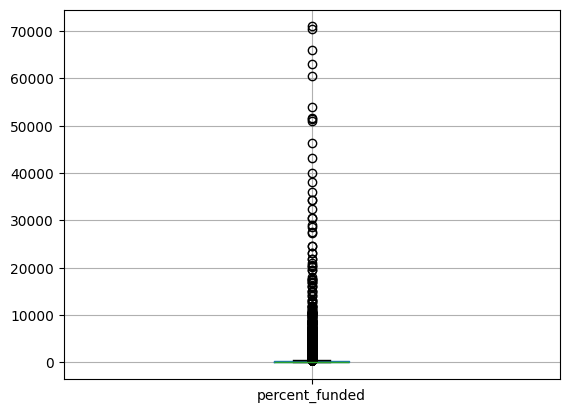

In [558]:
data.boxplot(column=['percent_funded'])
plt.show()

In [559]:
round(data.describe(),1)

,id,goal,pledged,deadline,state_changed_at,created_at,launched_at,backers_count,static_usd_rate,usd_pledged,percent_funded,creator_id,category_id,category_parent_id,video_id
count,1.337900e+04,13379.0,13379.0,13379,13379,13379,13379,13379.0,13379.0,13379.0,13379.0,1.337900e+04,13379.0,13379.0,11446.0
mean,1.067700e+09,26362.0,129535.9,2018-10-13 03:31:46.643247104,2018-10-08 02:40:38.713282304,2018-07-04 16:44:01.427236608,2018-09-10 02:08:17.091860480,367.0,1.0,47147.3,506.1,1.071980e+09,129.4,8.0,705442.6
min,1.971540e+05,1.0,0.0,2009-05-03 06:59:59,2009-05-03 07:00:17,2009-04-22 02:11:10,2009-04-24 19:52:03,0.0,0.0,0.0,0.0,8.000000e+00,1.0,0.0,111.0
25%,5.266090e+08,2500.0,3038.0,2013-08-23 00:50:16.500000,2013-08-23 00:50:16.500000,2013-05-18 16:52:28.500000,2013-07-24 16:56:50.500000,46.0,1.0,3006.1,105.0,5.303359e+08,22.0,1.0,225683.5
50%,1.070230e+09,6000.0,8279.0,2016-11-17 16:00:21,2016-11-17 16:00:21,2016-09-01 13:31:55,2016-10-18 15:00:21,107.0,1.0,8103.2,123.1,1.072192e+09,39.0,9.0,538035.5
75%,1.595158e+09,15000.0,25087.8,2025-09-23 00:15:26,2025-09-23 00:15:26.500000,2025-03-26 19:18:43,2025-08-21 16:45:01.500000,256.0,1.0,23435.0,223.7,1.604528e+09,263.0,14.0,1334443.5
max,2.147365e+09,20000000.0,95156996.0,2026-06-01 12:47:58,2026-04-02 13:20:58,2026-04-01 13:46:35,2026-04-02 13:20:55,48270.0,1.7,15133173.0,70946.0,2.147433e+09,396.0,26.0,1424018.0
std,6.176150e+08,254854.6,1713422.3,NaN,NaN,NaN,NaN,1330.3,0.2,300127.6,2309.6,6.207011e+08,128.4,6.7,526013.9


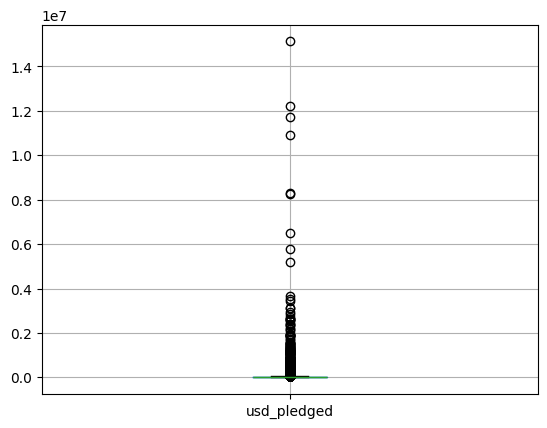

In [566]:
data.boxplot(column=['usd_pledged'])
plt.show()

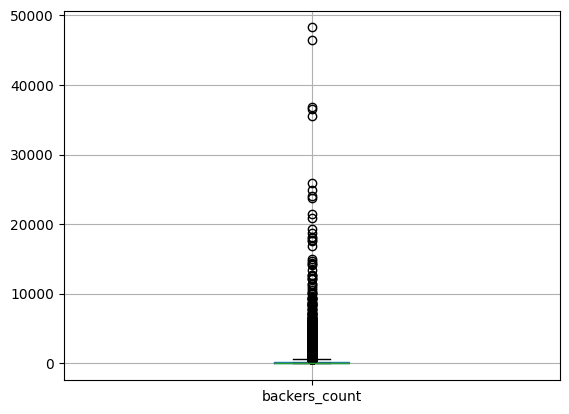

In [567]:
data.boxplot(column=['backers_count'])
plt.show()

In [560]:
data.sort_values(by='usd_pledged',ascending=False).head(20)
# здесь в целом все хорошо, крупные проекты набрали очень крупные суммы. Такое более чем нормальное явление для краудфандинга

,id,name,blurb,goal,pledged,state,country,country_displayable_name,currency,deadline,...,is_launched,prelaunch_activated,creator_id,creator_name,category_id,category_name,category_slug,category_parent_id,category_parent_name,video_id
3075,339473088,The Official Cyberpunk Trading Card Game,Build Your Crew. Earn Your Legend.,100000.0,15133173.00,live,US,the United States,USD,2026-04-17 23:00:00,...,True,True,1409909020,WeirdCo,34,Tabletop Games,games/tabletop games,12.0,Games,1420498.0
3431,870254269,NestWorks C500 - Next-Gen Smartest CNC with In...,"800W, 18,000 RPM Spindle | 10× Productivity | ...",388633.0,95156996.00,successful,HK,Hong Kong,HKD,2025-12-19 14:00:05,...,True,True,959480926,NestWorks,335,Fabrication Tools,technology/fabrication tools,16.0,Technology,1396477.0
3373,235978012,"Makera Z1 Desktop CNC: Entry-level CNC, Pro-le...",Metal / Wood / Endless Materials | Industrial-...,776800.0,91196239.00,successful,HK,Hong Kong,HKD,2025-12-12 16:00:03,...,True,True,1413242727,Makera,335,Fabrication Tools,technology/fabrication tools,16.0,Technology,1395310.0
8763,1323681751,Valerion VisionMaster: Cinematic-Grade RGB Las...,Most Funded Projector in Crowdfunding History ...,50000.0,10921452.00,successful,US,the United States,USD,2024-11-24 15:49:53,...,True,True,564709179,Valerion,337,Gadgets,technology/gadgets,16.0,Technology,1324908.0
3084,431199298,UGREEN AI NAS: Your Private Cloud Powered by S...,Intel® Core™ Ultra 7 | 96 TOPS Compute | 64GB ...,99999.0,8288439.00,live,US,the United States,USD,2026-04-23 15:00:09,...,True,True,1318535400,UGREEN,52,Hardware,technology/hardware,16.0,Technology,1421209.0
3376,27228399,Nebula X1 Pro: Mobile Theater with 4K Projecto...,"For Indoor, Backyard and Camping | Dolby Visio...",500000.0,8243797.00,successful,US,the United States,USD,2025-11-12 15:57:50,...,True,True,2099924322,soundcore Nebula,52,Hardware,technology/hardware,16.0,Technology,1388467.0
15652,83683256,Let's Make More MST3K & Build The Gizmoplex!,"Together, let's make more MYSTERY SCIENCE THEA...",2000000.0,6519019.57,successful,US,the United States,USD,2021-05-08 03:00:00,...,True,True,1587892087,Joel Hodgson,303,Television,film & video/television,11.0,Film & Video,1097343.0
15656,1454565733,Bring Back MYSTERY SCIENCE THEATER 3000,Almost there! MYSTERY SCIENCE THEATER 3000 wil...,2000000.0,5764229.38,successful,US,the United States,USD,2015-12-12 06:00:00,...,True,False,1587892087,Joel Hodgson,303,Television,film & video/television,11.0,Film & Video,607287.0
7862,762135312,Slay the Spire: The Board Game - Downfall,Reprint and expansion for the award-winning Sl...,50000.0,5214065.00,live,US,the United States,USD,2026-04-09 19:00:00,...,True,True,162568247,Contention Games,34,Tabletop Games,games/tabletop games,12.0,Games,1422208.0
3089,1461739904,"BB-777: The Iconic Boombox, Perfectly Recreated",A 270W modern boombox re-imagined from the ico...,50000.0,3645431.00,live,US,the United States,USD,2026-05-21 14:28:58,...,True,True,1840927321,Bumpboxx,337,Gadgets,technology/gadgets,16.0,Technology,1422274.0


создадим для аналитики столбец "сборы в день"

In [570]:
data.dtypes

,0
index,int64
id,int64
name,object
blurb,object
goal,float64
pledged,float64
state,object
country,object
country_displayable_name,object
currency,object


In [562]:
data['end'] = data['deadline'].where(data['deadline'] < pd.to_datetime('2026-04-02 00:00:00'),pd.to_datetime('2026-04-02 00:00:00'))

data['days'] = data['end'] - data['launched_at']
data['days'] = data['days'].dt.days
data = data[data['days']>0].reset_index()
data['usd_pledged_per_day'] = data['usd_pledged']/data['days']

In [563]:
data.head()

,index,id,name,blurb,goal,pledged,state,country,country_displayable_name,currency,...,creator_name,category_id,category_name,category_slug,category_parent_id,category_parent_name,video_id,end,days,usd_pledged_per_day
0,3431,870254269,NestWorks C500 - Next-Gen Smartest CNC with In...,"800W, 18,000 RPM Spindle | 10× Productivity | ...",388633.0,95156996.0,successful,HK,Hong Kong,HKD,...,NestWorks,335,Fabrication Tools,technology/fabrication tools,16.0,Technology,1396477.0,2025-12-19 14:00:05,45,272058.588268
1,3373,235978012,"Makera Z1 Desktop CNC: Entry-level CNC, Pro-le...",Metal / Wood / Endless Materials | Industrial-...,776800.0,91196239.0,successful,HK,Hong Kong,HKD,...,Makera,335,Fabrication Tools,technology/fabrication tools,16.0,Technology,1395310.0,2025-12-12 16:00:03,45,260882.446349
2,3425,1817989721,Mirumi: A Charm Robot that Steals a Glance—and...,"It spontaneously turns to you, and its innocen...",765000.0,79419523.0,successful,JP,Japan,JPY,...,Yukai Engineering,338,Robots,technology/robots,16.0,Technology,1402297.0,2026-01-22 12:00:06,50,10205.504009
3,8412,1165004003,Smartflex Camera SLR 4x5,Large Format SLR System,4800000.0,51143292.0,successful,JP,Japan,JPY,...,Zhuoyao Chen,333,Camera Equipment,technology/camera equipment,16.0,Technology,NaN,2025-01-22 01:13:55,30,10896.265886
4,3421,1173435412,"Melt Mouse: 3-in-1 mouse, trackpad, and shortc...","""The Melt Mouse Is A More Functional Version O...",5000000.0,49063717.0,successful,JP,Japan,JPY,...,Melt Interface,337,Gadgets,technology/gadgets,16.0,Technology,1395329.0,2025-11-15 15:59:00,18,17809.965725


In [564]:
round(data.describe())

,index,id,goal,pledged,deadline,state_changed_at,created_at,launched_at,backers_count,static_usd_rate,usd_pledged,percent_funded,creator_id,category_id,category_parent_id,video_id,end,days,usd_pledged_per_day
count,13347.0,1.334700e+04,13347.0,13347.0,13347,13347,13347,13347,13347.0,13347.0,13347.0,13347.0,1.334700e+04,13347.0,13347.0,11421.0,13347,13347.0,13347.0
mean,8604.0,1.067727e+09,26397.0,129842.0,2018-10-06 12:44:02.958417664,2018-10-01 13:26:38.063310080,2018-06-28 02:44:32.829549824,2018-09-03 11:17:31.661047552,368.0,1.0,47255.0,507.0,1.072175e+09,129.0,8.0,703875.0,2018-10-04 02:24:45.034539520,30.0,1901.0
min,1.0,1.971540e+05,1.0,0.0,2009-05-03 06:59:59,2009-05-03 07:00:17,2009-04-22 02:11:10,2009-04-24 19:52:03,0.0,0.0,0.0,0.0,8.000000e+00,1.0,0.0,111.0,2009-05-03 06:59:59,1.0,0.0
25%,4212.0,5.270055e+08,2500.0,3052.0,2013-08-19 20:55:35.500000,2013-08-19 20:55:36,2013-05-16 20:49:07.500000,2013-07-22 21:41:19.500000,47.0,1.0,3018.0,105.0,5.305289e+08,22.0,1.0,224847.0,2013-08-19 20:55:35.500000,25.0,109.0
50%,8456.0,1.070230e+09,6000.0,8300.0,2016-11-10 00:00:00,2016-11-10 00:00:00,2016-08-19 19:43:40,2016-10-12 12:38:57,107.0,1.0,8141.0,123.0,1.072397e+09,39.0,9.0,534852.0,2016-11-10 00:00:00,30.0,283.0
75%,12828.0,1.595390e+09,15000.0,25132.0,2025-09-15 16:49:05,2025-09-15 16:49:06,2025-03-19 15:44:47,2025-08-14 11:18:15,257.0,1.0,23545.0,224.0,1.604384e+09,263.0,14.0,1333345.0,2025-09-15 16:49:05,33.0,826.0
max,17438.0,2.147365e+09,20000000.0,95156996.0,2026-05-30 20:30:00,2026-04-02 12:03:17,2026-03-31 16:10:41,2026-03-31 22:10:39,48270.0,2.0,15133173.0,70946.0,2.147433e+09,396.0,26.0,1424018.0,2026-04-02 00:00:00,90.0,1036055.0
std,4965.0,6.175514e+08,255157.0,1715464.0,NaN,NaN,NaN,NaN,1332.0,0.0,300479.0,2312.0,6.204675e+08,128.0,7.0,525520.0,NaN,13.0,17903.0


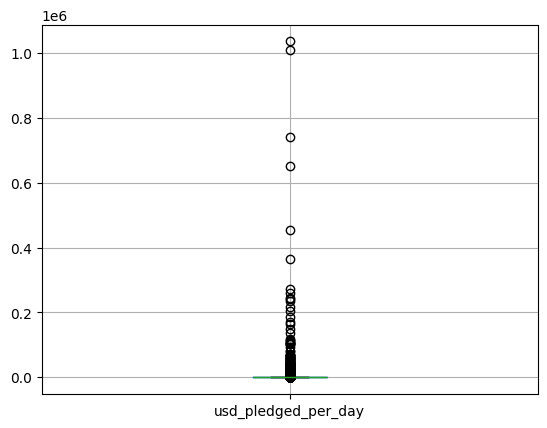

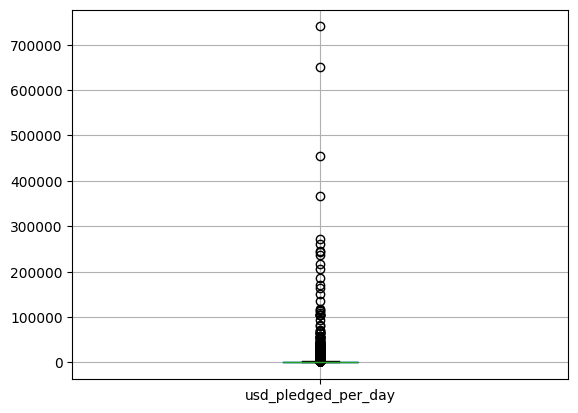

In [571]:
data.boxplot(column=['usd_pledged_per_day'])
plt.show()
data = data[data['usd_pledged_per_day']<1000000]
data.boxplot(column=['usd_pledged_per_day'])
plt.show()

In [572]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13345 entries, 0 to 13346
Data columns (total 34 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   index                               13345 non-null  int64         
 1   id                                  13345 non-null  int64         
 2   name                                13345 non-null  object        
 3   blurb                               13345 non-null  object        
 4   goal                                13345 non-null  float64       
 5   pledged                             13345 non-null  float64       
 6   state                               13345 non-null  object        
 7   country                             13345 non-null  object        
 8   country_displayable_name            13345 non-null  object        
 9   currency                            13345 non-null  object        
 10  deadline                   